In [2]:
from ultralytics import YOLO
import os 
import cv2
import matplotlib.pyplot as plt


In [3]:
dataset_path = "../data/vehicle_dataset"
print(os.listdir(dataset_path))

['images', 'labels', 'data.yaml']


In [4]:
model = YOLO("yolov8n.pt")

In [5]:
results = model.train(
    data="../data/vehicle_dataset/data.yaml",
    epochs=50,
    imgsz=416,
    batch=8,
    project="../results",
    name="vehicle_detector"
)   

Ultralytics 8.4.21 🚀 Python-3.11.15 torch-2.10.0+cpu CPU (11th Gen Intel Core i5-1135G7 @ 2.40GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/vehicle_dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=vehicle_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

In [11]:
print(os.listdir("runs/results"))

['vehicle_detector']


In [12]:
print(os.listdir("runs/results/vehicle_detector/weights"))

['last.pt', 'best.pt']


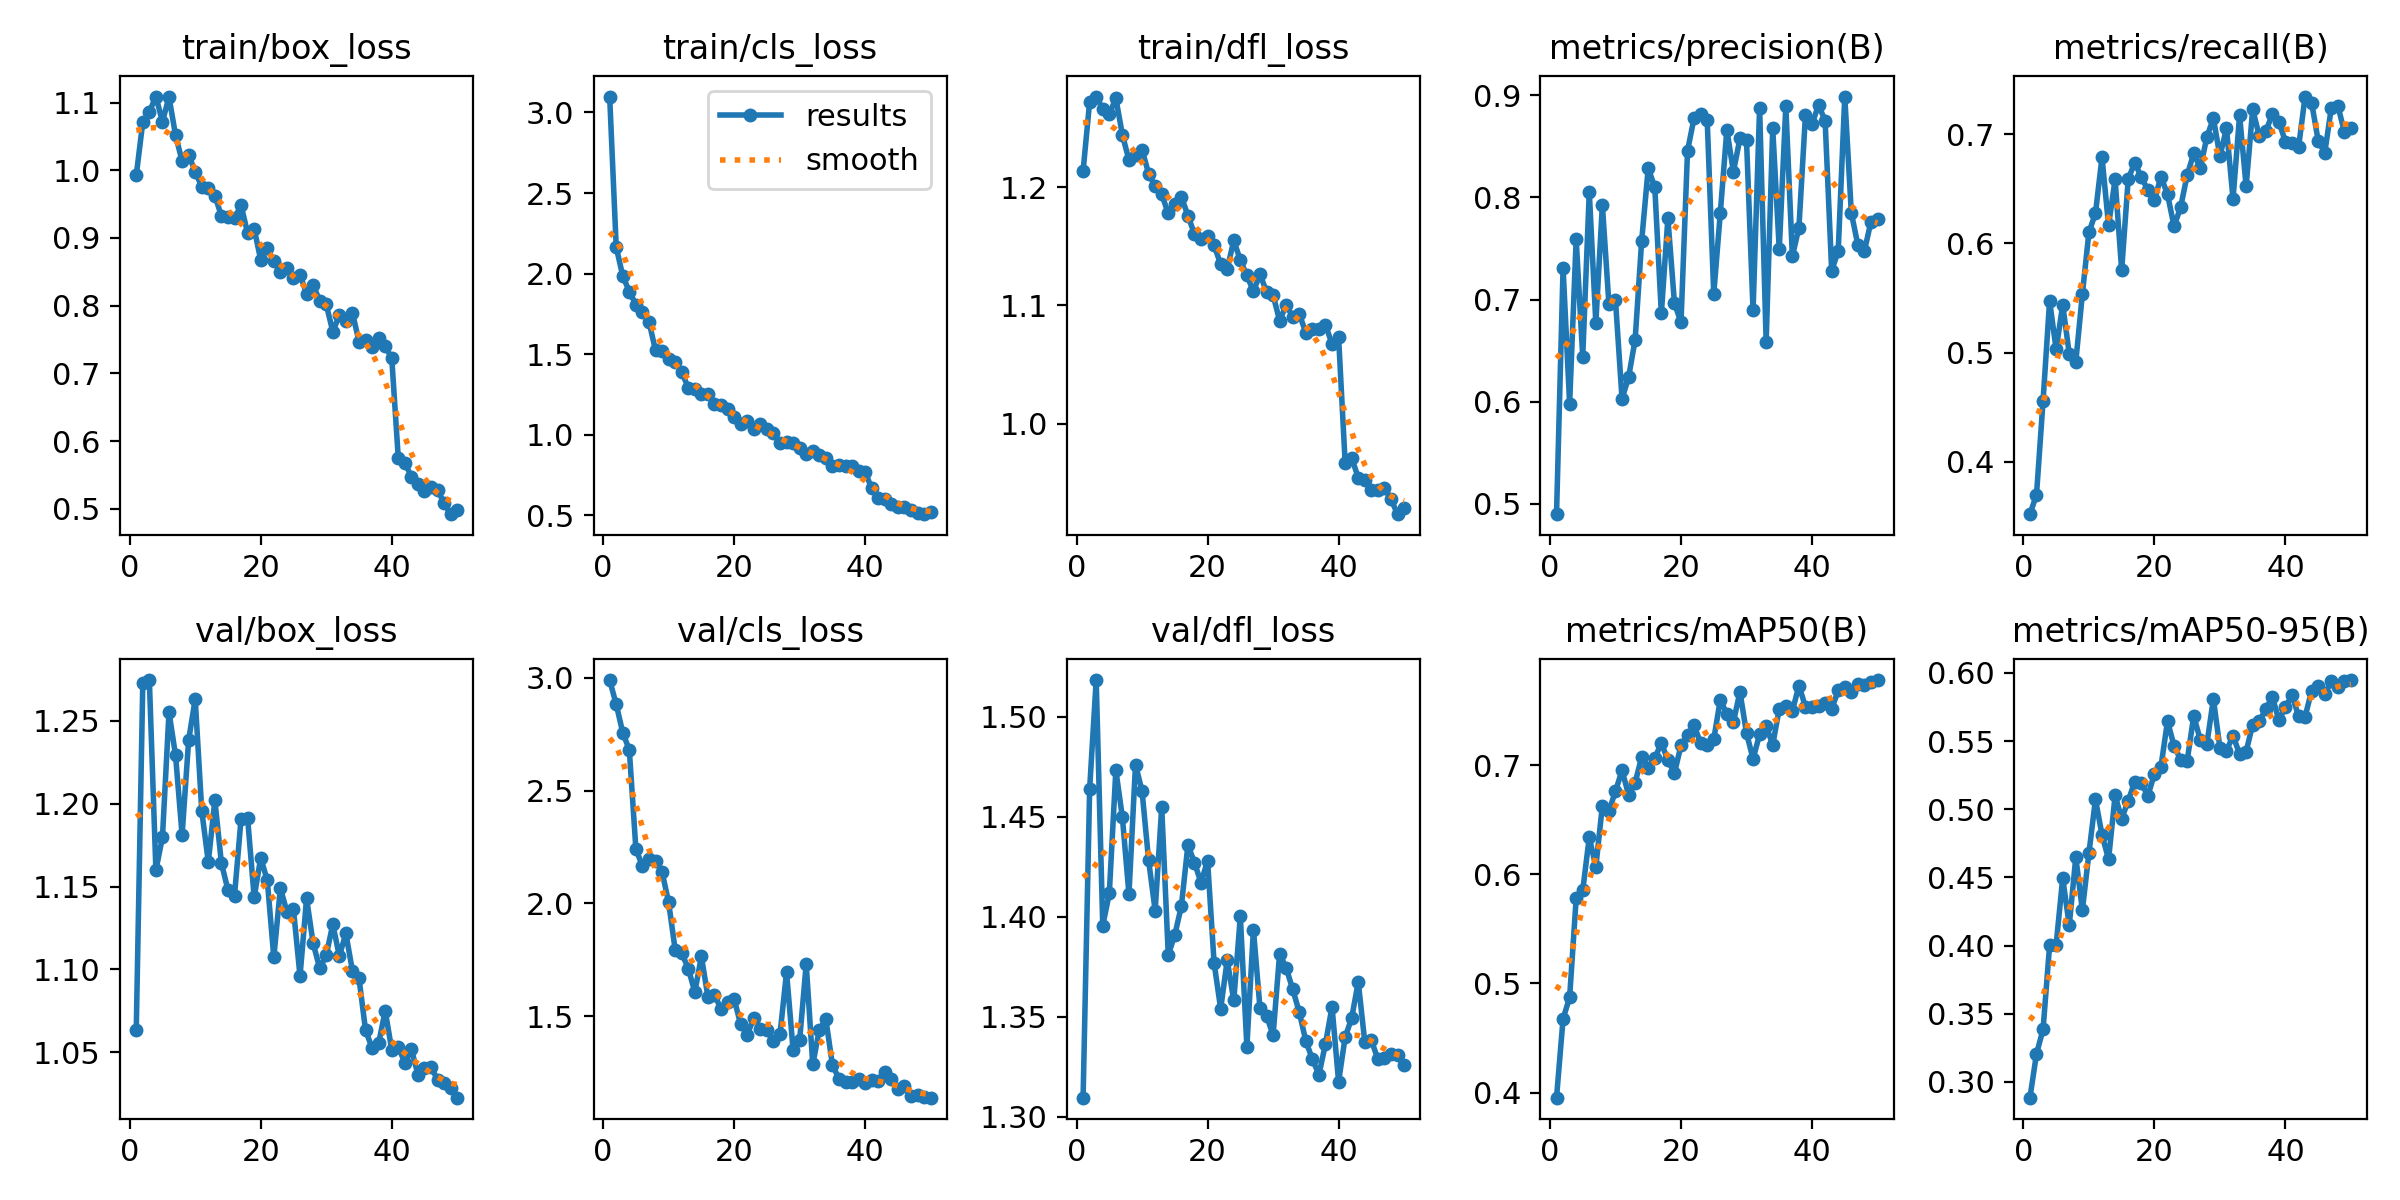

In [13]:
from IPython.display import Image

Image("runs/results/vehicle_detector/results.png")

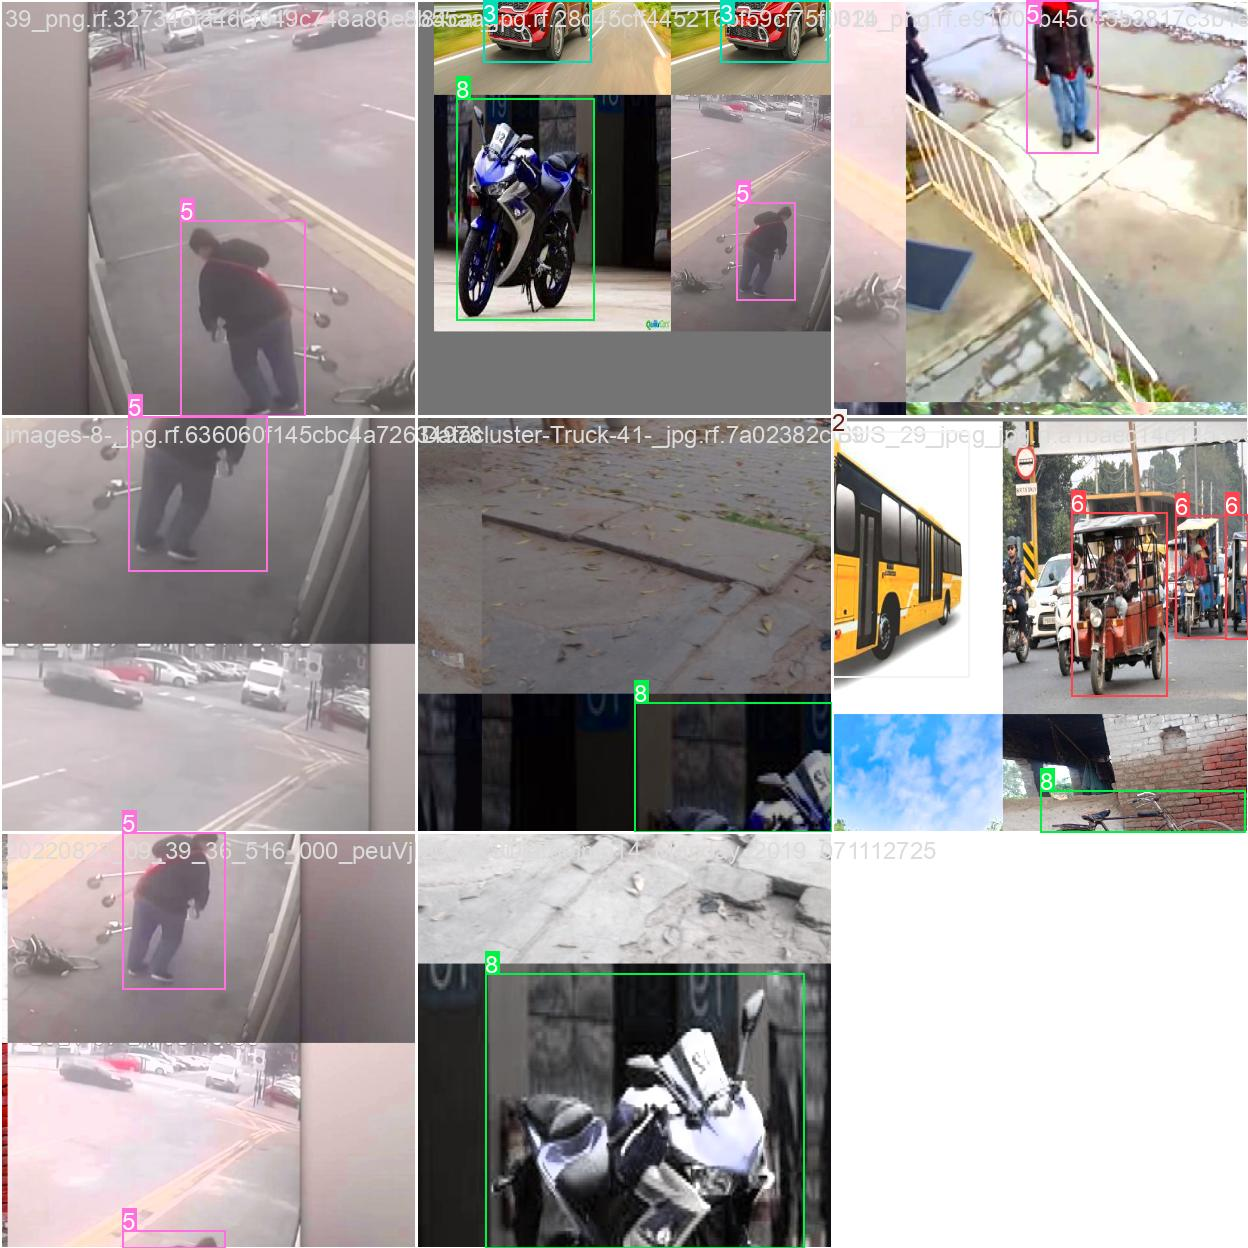

In [14]:
Image("runs/results/vehicle_detector/train_batch0.jpg")

In [15]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.21 🚀 Python-3.11.15 torch-2.10.0+cpu CPU (11th Gen Intel Core i5-1135G7 @ 2.40GHz)
Model summary (fused): 73 layers, 3,007,403 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1083.5±1362.7 MB/s, size: 74.4 KB)
val: Scanning /home/lurvik/Traffic_Anamoly_Detection/data/vehicle_dataset/labels/val.cache... 217 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 217/217 65.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 1.5it/s 9.1s0.6s
                   all        217        375      0.776      0.707      0.778      0.595
                Animal         24         27      0.987      0.889      0.934      0.735
                  Auto          6          6          0          0     0.0324     0.0218
                   Bus         16         16      0.941      0.875      0.976      0.788
                   Car         24         26      0.984      0.808      0.89

In [22]:
import shutil

src = "runs/results/vehicle_detector/weights/best.pt"
dst = "../models/vehicle_detector.pt"

shutil.copy(src, dst)

print("Model saved to models folder")

Model saved to models folder


In [18]:
model_test = YOLO("../models/vehicle_detector.pt")

model_test.predict(
    source="../data/videos/traffic_video.mp4",
    conf=0.25,
    save=True
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/557) /home/lurvik/Traffic_Anamoly_Detection/notebooks/../data/videos/traffic_video.mp4: 256x416 1 Person, 2 Two-wheelers, 112.5ms
video 1/1 (frame 2/557) /home/lurvik/Traffic_Anamoly_Detection/notebooks/../data/videos/traffic_video.mp4: 256x416 1 Person, 4 Two-wheelers, 34.9ms
video 1/1 (frame 3/557) /home/lurvik/Traffic_Anamoly_Detection/notebooks/../data/videos/traffic_video.mp4: 256x416 1 Person, 3 Two-wheelers, 59.1ms
video 1/1 (fr

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Animal', 1: 'Auto', 2: 'Bus', 3: 'Car', 4: 'Carts', 5: 'Person', 6: 'Rikshaw', 7: 'Truck', 8: 'Two-wheeler'}
 obb: None
 orig_img: array([[[205, 147, 123],
         [205, 147, 123],
         [205, 147, 123],
         ...,
         [204, 149, 129],
         [204, 149, 129],
         [204, 149, 129]],
 
        [[205, 147, 123],
         [205, 147, 123],
         [205, 147, 123],
         ...,
         [204, 149, 129],
         [204, 149, 129],
         [204, 149, 129]],
 
        [[205, 147, 123],
         [205, 147, 123],
         [205, 147, 123],
         ...,
         [204, 149, 129],
         [204, 149, 129],
         [204, 149, 129]],
 
        ...,
 
        [[114, 111, 112],
         [114, 111, 112],
         [114, 111, 112],
         ...,
         [106, 103, 104],
         [106, 103, 104],
         [106, 103, 104]],
 
        [[

In [20]:
import cv2

input_video = "runs/detect/predict/traffic_video.avi"
output_video = "runs/detect/predict/output.mp4"

cap = cv2.VideoCapture(input_video)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

while True:
    ret, frame = cap.read()
    if not ret:
        break
    out.write(frame)

cap.release()
out.release()

print("Conversion completed")

Conversion completed
